# 🐝 Swarm Behaviour

This Data Problem is a modified version of one of the questions that I asked during the assessment in 2021, so this give you a flair for the practical to come. Note that this is a relatively open-ended question. Generally, I also ask a few questions that are more targetted first, and the opened ended question comes at the end. The open ended question is really here for you to show how much you have learned as a data scientists. 

What I am looking for in an open-ended data science problem is:

1. A good solution to the problem asked
2. Clean code
3. That you demonstrate your skills. Remember, if you have not put it on the notebook, I don't see it, so I can't know you have done it (and I won't take your word for it)
4. I also don't want unnecessary code and approaches, and this can impact your grade negatively as it goes against clean code (point number 2).

## Run the cell below to load the data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

data = pd.read_csv('../Excercise_data/previous_assessments/swarm_training.csv')
unknown_behaviour =  pd.read_csv('../Excercise_data/previous_assessments/unknown_swarm_behaviour.csv')
data

,yC187,yC148,yC7,yC111,yC32,xC54,xC148,yC193,xC61,yC81,...,yS14,xS2,yS6,yC65,xC18,nS64,yC166,nS55,yS122,Swarm_Behaviour
0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.00,0.0,0.0,...,0.00,0.00,0.00,0.00,0.00,0.0,0.000,0.0,0.00,0.0
1,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.00,0.0,0.0,...,0.00,0.00,0.00,0.00,0.00,0.0,0.000,0.0,0.00,0.0
2,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.00,0.0,0.0,...,0.00,0.00,0.00,0.00,0.00,0.0,0.000,0.0,0.00,0.0
3,0.0,0.0,24.75,50.0,100.0,0.0,0.0,18.00,1.0,0.0,...,0.00,0.00,-0.79,12.50,-9.00,1.0,12.500,0.0,-1.19,1.0
4,0.0,50.0,24.75,50.0,100.0,0.0,-1.2,17.50,1.0,99.0,...,0.00,0.00,0.00,12.50,-2.25,1.0,12.500,0.0,-1.41,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3491,15.0,48.5,24.00,20.0,-85.0,0.0,-4.6,-19.25,3.0,4.0,...,0.00,0.00,0.00,-1.75,-12.75,0.0,10.750,0.0,0.00,1.0
3492,100.0,50.0,25.00,50.0,100.0,0.0,-0.4,25.00,-1.5,100.0,...,0.00,0.00,0.00,12.50,-0.75,0.0,12.500,1.0,0.00,1.0
3493,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.00,0.0,0.0,...,0.00,0.00,0.00,0.00,0.00,0.0,0.000,1.0,0.00,0.0
3494,-15.0,10.5,-2.00,0.5,-17.0,-19.0,-4.8,-1.00,-16.0,4.0,...,-0.64,-1.57,0.00,4.00,-8.00,1.0,1.125,1.0,0.00,1.0


## Dataset Description

This dataset is about flying species such as birds and insects, and whether they tend to form large groups and 'swarm' when they fly, or not. The dataset contains 50 `features` (different measurement of behaviour) and 1 label (`Swarm_Behaviour`).

`Swarm_Behaviour` can take the values 0 (*not swarming*) or 1 (*swarming*).

The dataset has already been cleaned, scaled and encoded for you, so you do not need to worry about it. 🧽

# What you need to do

You are a data scientist working for a non-profit looking at endangered eco-systems. You are given the dataset above, and are asked to train a `LogisticRegression` model to predict `Swarm_Behaviour` in new, unseen samples. 

Your bosses also give you the following directions:
* The algorithm needs to be a `LogisticRegression` algorithm - Upper management will discard any model more complex
* You need to train your model to achieve the highest possible **precision** using the labelled dataset (`data`) above 
* However, management requires your algorithm to have a **recall** of ***at least 70%***
* Once you are happy with your final trained algorithm, you are asked to save it into a variable named `final_model` 
* You are then asked to make predictions about the swarming behaviour of unclassified species given in the `unknown_behaviour` dataframe above, and to save your predictions in a variable named `predictions`

GOOD LUCK! 🧧

In [2]:
data.duplicated().sum()

np.int64(170)

In [3]:
data.drop_duplicates(inplace=True)
data.duplicated().sum()

np.int64(0)

In [4]:
unknown_behaviour.duplicated().sum()

np.int64(79)

In [5]:
unknown_behaviour.drop_duplicates(inplace=True)
unknown_behaviour.duplicated().sum()

np.int64(0)

In [6]:
X_train = data.drop(columns="Swarm_Behaviour")
y_train = data["Swarm_Behaviour"]
X_test = unknown_behaviour

In [7]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42, stratify=y_train)

In [8]:
y_train.value_counts()

Swarm_Behaviour
0.0    1755
1.0     905
Name: count, dtype: int64

In [9]:
X_train.describe()

,yC187,yC148,yC7,yC111,yC32,xC54,xC148,yC193,xC61,yC81,...,yS191,yS14,xS2,yS6,yC65,xC18,nS64,yC166,nS55,yS122
count,2660.000000,2660.000000,2660.000000,2660.000000,2660.000000,2660.000000,2660.000000,2660.000000,2660.000000,2660.000000,...,2660.000000,2660.000000,2660.000000,2660.000000,2660.000000,2660.000000,2660.000000,2660.000000,2660.000000,2660.000000
mean,2.236090,3.255827,1.344925,4.458835,9.816917,-4.640977,-1.717293,3.096617,-3.741729,7.298496,...,0.243613,-2.074744,-0.256891,0.184383,1.590320,-1.469267,1.157143,1.735620,0.656767,-0.129759
std,62.182633,31.299189,16.569019,31.694137,68.065456,57.012063,12.468304,15.651509,28.293192,65.498715,...,9.487210,30.041478,5.313827,14.912298,8.247879,14.919055,3.119430,8.448378,1.821648,2.273043
min,-268.000000,-134.000000,-67.000000,-134.000000,-268.000000,-268.000000,-53.600000,-67.000000,-134.000000,-268.000000,...,-106.890000,-948.910000,-143.620000,-240.940000,-33.500000,-67.000000,0.000000,-33.500000,0.000000,-37.170000
25%,-1.000000,-0.500000,-0.750000,-0.500000,-2.000000,-1.000000,-1.000000,-0.500000,-0.500000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,-1.500000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.062500,1.000000,3.000000,...,0.000000,0.000000,0.000000,0.000000,2.250000,0.000000,1.000000,1.250000,1.000000,0.000000
max,268.000000,134.000000,67.000000,134.000000,268.000000,268.000000,53.600000,67.000000,134.000000,268.000000,...,255.940000,38.760000,116.040000,269.570000,33.500000,67.000000,22.000000,33.500000,27.000000,62.460000


In [10]:
import numpy as np
np.unique(X_train.dtypes)

array([dtype('float64')], dtype=object)

In [11]:
X_train.dtypes.value_counts()

float64    291
Name: count, dtype: int64

In [12]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import RandomizedSearchCV

pipe = Pipeline([
    ("clf", LogisticRegression(max_iter=100000))
])

param_distributions = [
    # For L2 penalty (many solvers)
    {
        "clf__max_iter": [15000],
        'clf__solver': ['lbfgs', 'liblinear', 'saga'],
        'clf__penalty': ['l2'],
        'clf__C': np.logspace(-4, 4, 20),
        'clf__class_weight': [None, 'balanced']
    },
    # For L1 penalty
    {
        "clf__max_iter": [15000],
        'clf__solver': ['liblinear', 'saga'],
        'clf__penalty': ['l1'],
        'clf__C': np.logspace(-4, 4, 20),
        'clf__class_weight': [None, 'balanced']
    },
    # For Elastic Net
    {
        "clf__max_iter": [15000],
        'clf__solver': ['saga'],
        'clf__penalty': ['elasticnet'],
        'clf__l1_ratio': np.linspace(0, 1, 5),
        'clf__C': np.logspace(-4, 4, 20),
        'clf__class_weight': [None, 'balanced']
    }
]

search = RandomizedSearchCV(pipe, param_distributions, n_iter=10, cv=5, scoring="f1", random_state=42, n_jobs=-1)

In [13]:
search.fit(X_train, y_train)

/home/fgr25/miniconda3/envs/mpm2025/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 13574 iteration(s) (status=1):
STOP: TOTAL NO. OF F,G EVALUATIONS EXCEEDS LIMIT

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/home/fgr25/miniconda3/envs/mpm2025/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 13530 iteration(s) (status=1):
STOP: TOTAL NO. OF F,G EVALUATIONS EXCEEDS LIMIT

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/mod

,estimator,Pipeline(step...ter=100000))])
,param_distributions,"[{'clf__C': array([1.0000...00000000e+04]), 'clf__class_weight': [None, 'balanced'], 'clf__max_iter': [15000], 'clf__penalty': ['l2'], ...}, {'clf__C': array([1.0000...00000000e+04]), 'clf__class_weight': [None, 'balanced'], 'clf__max_iter': [15000], 'clf__penalty': ['l1'], ...}, ...]"
,n_iter,10
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [14]:
search.best_params_

{'clf__solver': 'lbfgs',
 'clf__penalty': 'l2',
 'clf__max_iter': 15000,
 'clf__class_weight': 'balanced',
 'clf__C': np.float64(0.012742749857031334)}

In [15]:
search.best_estimator_

,steps,"[('clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,penalty,'l2'
,dual,False
,tol,0.0001
,C,np.float64(0....2749857031334)
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'


In [16]:
search.best_score_

np.float64(0.8342491986916907)

In [17]:
from sklearn.metrics import f1_score, precision_recall_curve, precision_score, recall_score

best_model = search.best_estimator_
best_model.fit(X_train, y_train)

y_val_pred_prob = best_model.predict_proba(X_val)[:, 1]

thresholds = np.linspace(0.01, 0.99, 99)
precision_scores = []
recall_scores = []
f1_scores = []

for t in thresholds:
    y_pred_t = np.zeros(len(y_val_pred_prob))
    y_pred_t = [1 if y > t else 0 for y in y_val_pred_prob]
    precision_scores.append(precision_score(y_val, y_pred_t))
    recall_scores.append(recall_score(y_val, y_pred_t))
    f1_scores.append(f1_score(y_val, y_pred_t))


In [18]:
idx = np.argmax(precision_scores)
print(f"Highest Precision ({precision_scores[idx]}) achieved for threshold: {thresholds[idx]}")
print(f"Recall of ({recall_scores[idx]}) achieved for threshold: {thresholds[idx]}")
print(f"F1 Score ({f1_scores[idx]}) achieved for threshold: {thresholds[idx]}")

Highest Precision (0.9) achieved for threshold: 0.98
Recall of (0.7566371681415929) achieved for threshold: 0.98
F1 Score (0.8221153846153846) achieved for threshold: 0.98


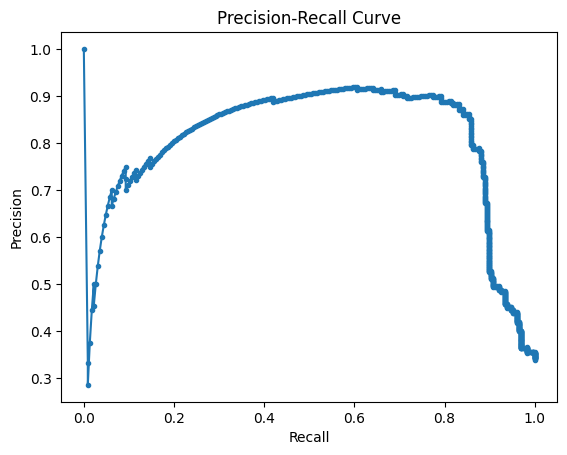

In [19]:
import matplotlib.pyplot as plt

precision, recall, thresholds = precision_recall_curve(y_val, y_val_pred_prob)

plt.plot(recall, precision, marker='.')
plt.title('Precision-Recall Curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.show()


In [20]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    precision_recall_curve, average_precision_score,
    precision_score, recall_score, confusion_matrix
)
from ipywidgets import interact, FloatSlider

# Scores on TEST
y_scores = best_model.predict_proba(X_val)[:, 1]
prec_curve, rec_curve, _ = precision_recall_curve(y_val, y_scores)
ap = average_precision_score(y_val, y_scores)

def show_threshold(threshold=0.50):
    # Binarize at chosen threshold
    y_pred = (y_scores >= threshold).astype(int)
    p = precision_score(y_val, y_pred, zero_division=0)
    r = recall_score(y_val, y_pred, zero_division=0)
    cm = confusion_matrix(y_val, y_pred)

    # PR curve
    plt.figure(figsize=(6,5))
    plt.plot(rec_curve, prec_curve, label=f'PR curve (AP={ap:.3f})')
    plt.scatter(r, p, color='red', label=f'@ thr={threshold:.2f}')
    plt.xlabel('Recall'); plt.ylabel('Precision')
    plt.title('Precision–Recall (TEST)')
    plt.legend(); plt.grid(True); plt.show()

    # Confusion matrix
    plt.figure(figsize=(4.6,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Negative','Positive'],
                yticklabels=['Negative','Positive'])
    plt.xlabel('Predicted'); plt.ylabel('True')
    plt.title(f'Confusion Matrix @ thr={threshold:.2f}'); plt.tight_layout(); plt.show()

interact(show_threshold, threshold=FloatSlider(min=0.01, max=0.99, step=0.01, value=0.50))

interactive(children=(FloatSlider(value=0.5, description='threshold', max=0.99, min=0.01, step=0.01), Output()…

<function __main__.show_threshold(threshold=0.5)>

In [21]:
thresholds = np.linspace(0.01, 0.99, 99)
thresholds[65]

np.float64(0.66)

In [22]:
idx = 65
print(f"Highest Precision ({precision_scores[idx]}) achieved for threshold: {thresholds[idx]}")
print(f"Recall of ({recall_scores[idx]}) achieved for threshold: {thresholds[idx]}")
print(f"F1 Score ({f1_scores[idx]}) achieved for threshold: {thresholds[idx]}")

Highest Precision (0.867579908675799) achieved for threshold: 0.66
Recall of (0.8407079646017699) achieved for threshold: 0.66
F1 Score (0.8539325842696629) achieved for threshold: 0.66


# Optional Extension

If you are done with the previous exercise, you are free to try `Ensemble methods` (including `XGBoost`) to see if you can outperform the `LogisticRegression`). Have fun!

In [23]:
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV

best_lr = best_model

pipe = Pipeline([
    ("clf", best_model)
])

param_grid = [
    {
        "clf": [RandomForestClassifier(random_state=42)],
        "clf__n_estimators": [200, 400],
        "clf__max_depth": [None, 10, 20],
    },
    {
        "clf": [AdaBoostClassifier(random_state=42)],
        "clf__n_estimators": [100, 200],
        "clf__learning_rate": [0.1, 0.5, 1.0],
    },
    {
        "clf": [GradientBoostingClassifier(random_state=42)],
        "clf__n_estimators": [100, 200],
        "clf__learning_rate": [0.05, 0.1],
        "clf__max_depth": [2, 3],
    },
    {
        "clf": [XGBClassifier(random_state=42, eval_metric="logloss")],
        "clf__n_estimators": [200, 400],
        "clf__max_depth": [3, 6],
        "clf__subsample": [0.8, 1.0],
    },
]

search = GridSearchCV(pipe, param_grid, cv=5, scoring="precision", n_jobs=-1)
search.fit(X_train, y_train)

,estimator,Pipeline(step...r=15000))]))])
,param_grid,"[{'clf': [RandomForestC...ndom_state=42)], 'clf__max_depth': [None, 10, ...], 'clf__n_estimators': [200, 400]}, {'clf': [AdaBoostClass...ndom_state=42)], 'clf__learning_rate': [0.1, 0.5, ...], 'clf__n_estimators': [100, 200]}, ...]"
,scoring,'precision'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,estimator,None


In [24]:
best_model = search.best_estimator_

In [25]:
search.best_score_

np.float64(0.8903788383690809)

In [26]:
0.21, 0.79

(0.21, 0.79)

In [27]:
best_model.fit(X_train, y_train)

y_val_pred_prob = best_model.predict_proba(X_val)[:, 1]
thresholds = np.linspace(0.21, 0.69, 49)
precision_scores = []
recall_scores = []
f1_scores = []

for t in thresholds:
    y_pred_t = np.zeros(len(y_val_pred_prob))
    y_pred_t = [1 if y > t else 0 for y in y_val_pred_prob]
    precision_scores.append(precision_score(y_val, y_pred_t))
    recall_scores.append(recall_score(y_val, y_pred_t))
    f1_scores.append(f1_score(y_val, y_pred_t))

In [28]:
idx = np.argmax(precision_scores)
print(f"Highest Precision ({precision_scores[idx]}) achieved for threshold: {thresholds[idx]}")
print(f"Recall of ({recall_scores[idx]}) achieved for threshold: {thresholds[idx]}")
print(f"F1 Score ({f1_scores[idx]}) achieved for threshold: {thresholds[idx]}")

Highest Precision (1.0) achieved for threshold: 0.59
Recall of (0.6592920353982301) achieved for threshold: 0.59
F1 Score (0.7946666666666666) achieved for threshold: 0.59


In [29]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    precision_recall_curve, average_precision_score,
    precision_score, recall_score, confusion_matrix
)
from ipywidgets import interact, FloatSlider

# Scores on TEST
y_scores = best_model.predict_proba(X_val)[:, 1]
prec_curve, rec_curve, _ = precision_recall_curve(y_val, y_scores)
ap = average_precision_score(y_val, y_scores)

def show_threshold(threshold=0.50):
    # Binarize at chosen threshold
    y_pred = (y_scores >= threshold).astype(int)
    p = precision_score(y_val, y_pred, zero_division=0)
    r = recall_score(y_val, y_pred, zero_division=0)
    cm = confusion_matrix(y_val, y_pred)

    # PR curve
    plt.figure(figsize=(6,5))
    plt.plot(rec_curve, prec_curve, label=f'PR curve (AP={ap:.3f})')
    plt.scatter(r, p, color='red', label=f'@ thr={threshold:.2f}')
    plt.xlabel('Recall'); plt.ylabel('Precision')
    plt.title('Precision–Recall (TEST)')
    plt.legend(); plt.grid(True); plt.show()

    # Confusion matrix
    plt.figure(figsize=(4.6,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Negative','Positive'],
                yticklabels=['Negative','Positive'])
    plt.xlabel('Predicted'); plt.ylabel('True')
    plt.title(f'Confusion Matrix @ thr={threshold:.2f}'); plt.tight_layout(); plt.show()

interact(show_threshold, threshold=FloatSlider(min=0.01, max=0.99, step=0.01, value=0.50))

interactive(children=(FloatSlider(value=0.5, description='threshold', max=0.99, min=0.01, step=0.01), Output()…

<function __main__.show_threshold(threshold=0.5)>

In [30]:
# thresholds = np.linspace(0.21, 0.79, 59)
thresholds = np.linspace(0.21, 0.69, 49)
thresholds[36]

np.float64(0.57)

In [31]:
idx = 36
print(f"Highest Precision ({precision_scores[idx]}) achieved for threshold: {thresholds[idx]}")
print(f"Recall of ({recall_scores[idx]}) achieved for threshold: {thresholds[idx]}")
print(f"F1 Score ({f1_scores[idx]}) achieved for threshold: {thresholds[idx]}")

Highest Precision (0.9879518072289156) achieved for threshold: 0.57
Recall of (0.7256637168141593) achieved for threshold: 0.57
F1 Score (0.8367346938775511) achieved for threshold: 0.57
